In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

In [4]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Praktikum_DM/Hospital_Indonesia_datasets.csv', sep=';')

df.head()

,id,nama,propinsi,kab,alamat,jenis,kelas,status_blu,kepemilikan,total_tempat_tidur,total_layanan,total_tenaga_kerja
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,Rumah Sakit Umum,C,Non BLU/BLUD,SWASTA/LAINNYA,218,36,328
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,Rumah Sakit Umum,D,Non BLU/BLUD,SWASTA/LAINNYA,45,15,45
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,Rumah Sakit Umum,B,BLUD,Pemkot,310,77,487
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,Rumah Sakit Khusus Gigi dan Mulut,B,BLU,Kementerian Lain,11,24,0
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) K...,Rumah Sakit Umum,C,BLUD,Pemkot,189,34,537


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3155 entries, 0 to 3154
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  3155 non-null   int64 
 1   nama                3155 non-null   object
 2   propinsi            3155 non-null   object
 3   kab                 3155 non-null   object
 4   alamat              3155 non-null   object
 5   jenis               3155 non-null   object
 6   kelas               3155 non-null   object
 7   status_blu          3155 non-null   object
 8   kepemilikan         3155 non-null   object
 9   total_tempat_tidur  3155 non-null   int64 
 10  total_layanan       3155 non-null   int64 
 11  total_tenaga_kerja  3155 non-null   int64 
dtypes: int64(4), object(8)
memory usage: 295.9+ KB


In [6]:
print(f"Jenis: \n {df['jenis'].unique()}\n")
print(f"Kelas: \n {df['kelas'].unique()}\n")
print(f"Status_blu: \n {df['status_blu'].unique()}\n")
print(f"Kepemilikan: \n {df['kepemilikan'].unique()}\n")

Jenis: 
 ['Rumah Sakit Umum' 'Rumah Sakit Khusus Gigi dan Mulut'
 'Rumah Sakit Khusus Ibu dan Anak' 'Rumah Sakit Khusus Jiwa'
 'Rumah Sakit Khusus Bedah' 'Rumah Sakit Khusus Mata'
 'Rumah Sakit Khusus Paru' 'Rumah Sakit Khusus Ginjal'
 'Rumah Sakit Khusus Stroke' 'Rumah Sakit Khusus THT-KL'
 'Rumah Sakit Khusus Kanker' 'Rumah Sakit Khusus Infeksi' '021-26071997'
 'Rumah Sakit Khusus Jantung' 'Rumah Sakit Khusus Otak'
 'Rumah Sakit Ketergantungan Obat' 'Rumah Sakit Khusus Orthopedi'
 'RS Kapal/Bergerak' '2' ' ' '-']

Kelas: 
 ['C' 'D' 'B' 'D PRATAMA' 'A' 'Belum Ditetapkan' 'Rumah Sakit Umum'
 'Rumah Sakit Khusus Jiwa']

Status_blu: 
 ['Non BLU/BLUD' 'BLUD' 'BLU' 'D' 'A' 'C' 'D PRATAMA']

Kepemilikan: 
 ['SWASTA/LAINNYA' 'Pemkot' 'Kementerian Lain' 'Pemkab' 'Perusahaan'
 'Organisasi Sosial' 'POLRI' 'TNI AD' 'TNI AL' 'BUMN' 'Pemprop'
 'Perorangan' 'Organisasi Katholik' 'Organisasi Protestan' 'Kemkes '
 'TNI AU' 'Organisasi Islam ' 'Organisasi Budha' 'BLUD' 'BLU'
 'Non BLU/BLUD' 'Organisas

# **Cleaning**

In [8]:
df[df['kelas'] == 'D PRATAMA'][['nama', 'kelas', 'jenis']]

,nama,kelas,jenis
25,RS Umum Daerah Type D Pratama T. Cut Ali,D PRATAMA,Rumah Sakit Umum
32,RS Umum Daerah dr. Muchtar Hasbi,D PRATAMA,Rumah Sakit Umum
99,RS Pratama Kab. Nias Barat,D PRATAMA,Rumah Sakit Umum
244,RS Pratama Lologolu Soguna Ba Zato,D PRATAMA,Rumah Sakit Umum
312,RS Umum Daerah Kamang Baru,D PRATAMA,Rumah Sakit Umum
...,...,...,...
3117,RS Umum Daerah Pratama Dogiyai,D PRATAMA,Rumah Sakit Umum
3138,RS Umum Daerah Ilaga,D PRATAMA,Rumah Sakit Umum
3144,RS Bergerak Kab. Boven Digoel,D PRATAMA,Rumah Sakit Umum
3146,RS Umum Daerah Karubaga,D PRATAMA,Rumah Sakit Umum


In [9]:
df[df['kelas'] == 'Rumah Sakit Khusus Jiwa'][['nama', 'kelas', 'jenis']]

,nama,kelas,jenis
1746,RS Khusus Jiwa Puri Nirmala,Rumah Sakit Khusus Jiwa,


In [10]:
df.loc[
    df['nama'] == 'RS Umum Daerah Kepulauan Seribu',
    'kelas'
] = 'D'

df.loc[
    df['nama'] == 'RS Umum Pusat Dr. Soeradji Tirtonegoro',
    'kelas'
] = 'A'

df.loc[
    df['nama'] == 'RS Umum Daerah Kawera',
    'kelas'
] = 'D PRATAMA'

df.loc[
    df['kelas'] == 'Rumah Sakit Khusus Jiwa',
    'kelas'
] = 'C'

In [11]:
kelas_mapping = {
    'A': 4,
    'B': 3,
    'C': 2,
    'D': 1,
    'D PRATAMA': 0,
    'Belum Ditetapkan': -1 # untuk nandain kalau belum ada kelasnya yang mana beda dengan nilai yang lain
}

df['kelas'] = df['kelas'].map(kelas_mapping)

In [12]:
df = pd.get_dummies(
    df,
    columns=['jenis', 'kepemilikan']
)

In [13]:
df.head()

,id,nama,propinsi,kab,alamat,kelas,status_blu,total_tempat_tidur,total_layanan,total_tenaga_kerja,...,kepemilikan_POLRI,kepemilikan_Pemkab,kepemilikan_Pemkot,kepemilikan_Pemprop,kepemilikan_Perorangan,kepemilikan_Perusahaan,kepemilikan_SWASTA/LAINNYA,kepemilikan_TNI AD,kepemilikan_TNI AL,kepemilikan_TNI AU
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,2,Non BLU/BLUD,218,36,328,...,False,False,False,False,False,False,True,False,False,False
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,1,Non BLU/BLUD,45,15,45,...,False,False,False,False,False,False,True,False,False,False
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,3,BLUD,310,77,487,...,False,False,True,False,False,False,False,False,False,False
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,3,BLU,11,24,0,...,False,False,False,False,False,False,False,False,False,False
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) K...,2,BLUD,189,34,537,...,False,False,True,False,False,False,False,False,False,False


# **Feature Selection**

In [14]:
df_cluster = df.drop(columns=['id', 'nama', 'propinsi', 'kab', 'alamat', 'status_blu'])

# **Normalisasi**

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# **Modelling**

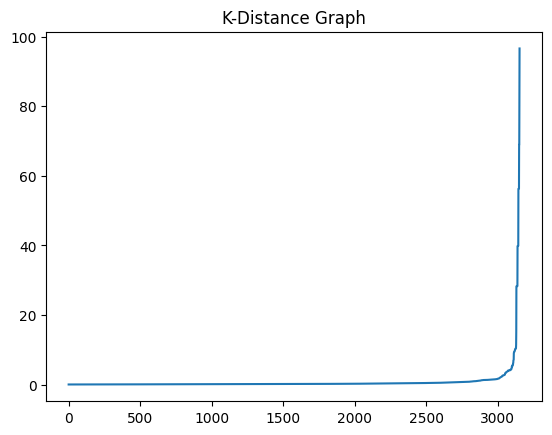

In [16]:
neighbors = NearestNeighbors(n_neighbors=5)
distances, _ = neighbors.fit(X_scaled).kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title('K-Distance Graph')
plt.show()

In [18]:
best_score = -1

for eps in np.arange(2, 5.1, 0.1):

  for min_samples in range(120, 140):
    model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )
    labels = model.fit_predict(X_scaled)

    # Cek jumlah Cluster
    if len(set(labels)) > 2:
      score = silhouette_score(X_scaled, labels)

      # Simpan model terbaik
      if score > best_score:
        best_score = score
        best_eps = eps
        best_min_samples = min_samples
        best_labels = labels

# **Evaluasi**

In [19]:
print("Best EPS: ", best_eps)
print("Best Min Samples: ", best_min_samples)

print(
    "Best Silhouette Score: ",
    round(best_score, 4)
)

Best EPS:  3.000000000000001
Best Min Samples:  120
Best Silhouette Score:  0.2865


In [20]:
unique, counts = np.unique(best_labels, return_counts=True)
for label, count in zip(unique, counts):
  if label == -1:
    print(f"Noise: {count} titik")
  else:
    print(f"Cluster {label}: {count} titik")

Noise: 1046 titik
Cluster 0: 668 titik
Cluster 1: 645 titik
Cluster 2: 395 titik
Cluster 3: 152 titik
Cluster 4: 249 titik


In [22]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

clusters = dbscan.fit_predict(X_scaled)
df['cluster'] = clusters

In [24]:
cluster_summary = df.groupby('cluster')[[
  'total_tempat_tidur',
  'total_layanan',
  'total_tenaga_kerja'
]].mean()

print(cluster_summary)

         total_tempat_tidur  total_layanan  total_tenaga_kerja
cluster                                                       
-1               165.561185      41.091778          310.665392
 0               115.775449      44.964072          200.770958
 1               146.398450      39.699225          337.310078
 2               118.660759      44.220253          194.858228
 3                38.875000      19.559211           63.078947
 4               118.763052      42.562249          254.441767


In [26]:
# PCA 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# buat dataframe sederhana
df_plot = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'cluster': clusters
})

# 3D interactive plot
fig = px.scatter_3d(
    df_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='cluster',
    title='DBSCAN + PCA 3D (Interactive)'
)

fig.show()